# Анализ продаж автомобилей в РБ — "лист 3"

Источник данных: Google Sheets
`https://docs.google.com/spreadsheets/d/1UXuXCuYDSM4LR6ofEf5MEbT2zDklDyItukczhkGDTGA`, вкладка **лист 3**.


Задание 3:
1. Какие бренды наиболее популярны?
2. Доля Volkswagen в Гомельской области?
3. Доля Kia Sportage в сегменте?
4. Основные конкуренты Volkswagen Tiguan?


In [1]:
import pandas as pd
import openpyxl
import requests
from io import StringIO

SHEET_ID = "1UXuXCuYDSM4LR6ofEf5MEbT2zDklDyItukczhkGDTGA"
GID = "1733098164"  # gid листа "лист 3"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"
LOCAL_FILE = "ТЗ_ананалитик.xlsx"
SHEET_NAME = "лист 3"

df = None

# 1) Пробуем скачать напрямую из Google Sheets (сработает, если доступ открыт по ссылке)
try:
    resp = requests.get(CSV_URL, timeout=10)
    resp.raise_for_status()
    if "text/csv" in resp.headers.get("Content-Type", ""):
        df = pd.read_csv(StringIO(resp.text))
        print("Данные загружены напрямую из Google Sheets (CSV export).")
except Exception as e:
    print(f"Не удалось скачать напрямую из Google Sheets: {e}")

# 2) Фолбэк — локальная копия файла (таблица закрыта для анонимного экспорта)
if df is None or df.shape[0] < 10:
    wb = openpyxl.load_workbook(LOCAL_FILE, data_only=True)
    ws = wb[SHEET_NAME]
    rows = [row for row in ws.iter_rows(min_row=2, max_col=8, values_only=True) if row[0] is not None]
    df = pd.DataFrame(rows, columns=[
        "Месяц", "Год", "тип", "класс", "подкласс",
        "Марка_модель", "Владелец", "Область"
    ])
    print("Данные загружены из локальной копии файла (fallback).")

print(f"Всего строк: {df.shape[0]}")
df.head()


Не удалось скачать напрямую из Google Sheets: 403 Client Error: Forbidden for url: https://docs.google.com/spreadsheets/d/1UXuXCuYDSM4LR6ofEf5MEbT2zDklDyItukczhkGDTGA/export?format=csv&gid=1733098164


Данные загружены из локальной копии файла (fallback).
Всего строк: 5999


,Месяц,Год,тип,класс,подкласс,Марка_модель,Владелец,Область
0,Январь,2009,nfz,Transporter,C,Peugeot Boxer,Юридическое лицо,МИНСК
1,Март,2009,pkw,Hatchback,A0,Skoda Fabia,Юридическое лицо,ГРОДНЕНСКАЯ ОБЛАСТЬ
2,Ноябрь,2011,pkw,Sedan,A0,Kia Rio,Физическое лицо,ГРОДНЕНСКАЯ ОБЛАСТЬ
3,Декабрь,2011,pkw,Hatchback,A,Volkswagen Golf,Физическое лицо,ГРОДНЕНСКАЯ ОБЛАСТЬ
4,Апрель,2008,pkw,SUV,A,Mitsubishi Outlander,Физическое лицо,МИНСК


## Подготовка данных: извлечение бренда из столбца «Марка + модель»

In [2]:
# Некоторые бренды состоят из двух слов — учитываем это явно
TWO_WORD_BRANDS = ["Great Wall", "Land Rover", "Mercedes-Benz"]

def get_brand(model: str) -> str:
    for b in TWO_WORD_BRANDS:
        if model.startswith(b):
            return b
    return model.split()[0]

df["Бренд"] = df["Марка_модель"].apply(get_brand)
df[["Марка_модель", "Бренд"]].drop_duplicates().head(10)


,Марка_модель,Бренд
0,Peugeot Boxer,Peugeot
1,Skoda Fabia,Skoda
2,Kia Rio,Kia
3,Volkswagen Golf,Volkswagen
4,Mitsubishi Outlander,Mitsubishi
5,Kia Optima,Kia
7,Volkswagen Crafter,Volkswagen
8,Renault Sandero,Renault
10,Volkswagen Polo Sedan,Volkswagen
11,Renault Duster,Renault


## 1) Какие бренды наиболее популярны?

In [3]:
brand_counts = df["Бренд"].value_counts()
brand_share = (brand_counts / brand_counts.sum() * 100).round(2)

top_brands = pd.DataFrame({
    "Продажи (шт.)": brand_counts,
    "Доля рынка (%)": brand_share
}).head(10)
top_brands


,Продажи (шт.),Доля рынка (%)
Бренд,,
Volkswagen,914,15.24
Renault,751,12.52
Kia,541,9.02
Hyundai,427,7.12
Nissan,402,6.70
Skoda,355,5.92
Toyota,324,5.40
Ford,223,3.72
Chevrolet,213,3.55


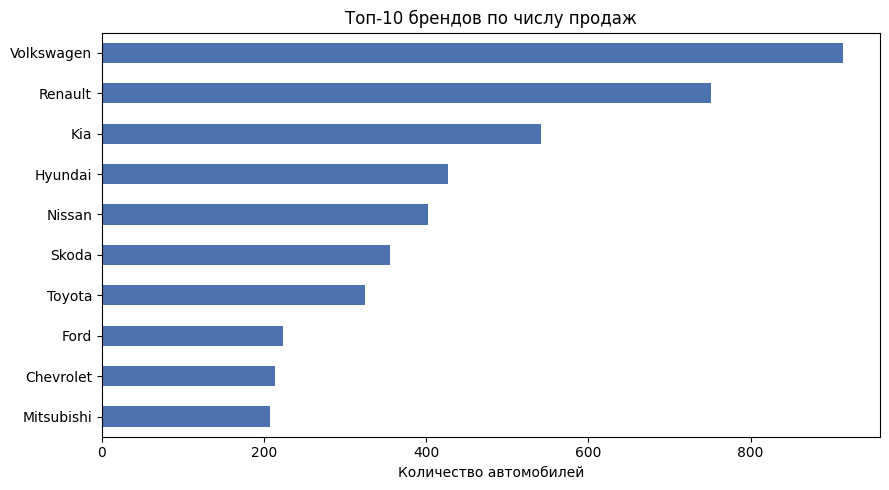

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
top_brands["Продажи (шт.)"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Топ-10 брендов по числу продаж")
ax.set_xlabel("Количество автомобилей")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


**Вывод:** самый популярный бренд — **Volkswagen** (~15% рынка), далее следуют **Renault** (~12.5%) и **Kia** (~9%).
В топ-7 также входят Hyundai, Nissan, Skoda и Toyota — на них суммарно приходится больше половины всех продаж.

## 2) Доля Volkswagen в Гомельской области?

In [5]:
gomel = df[df["Область"] == "ГОМЕЛЬСКАЯ ОБЛАСТЬ"]
vw_gomel = gomel[gomel["Бренд"] == "Volkswagen"]

vw_share_gomel = len(vw_gomel) / len(gomel) * 100

print(f"Всего продаж в Гомельской области: {len(gomel)}")
print(f"Из них Volkswagen: {len(vw_gomel)}")
print(f"Доля Volkswagen в Гомельской области: {vw_share_gomel:.2f}%")


Всего продаж в Гомельской области: 570
Из них Volkswagen: 86
Доля Volkswagen в Гомельской области: 15.09%


In [6]:
# Для сравнения — доля VW по всем областям
by_region = df.groupby("Область").apply(
    lambda g: (g["Бренд"] == "Volkswagen").sum() / len(g) * 100
).round(2).sort_values(ascending=False)
by_region.to_frame("Доля VW (%)")


,Доля VW (%)
Область,
БРЕСТСКАЯ ОБЛАСТЬ,22.16
ГРОДНЕНСКАЯ ОБЛАСТЬ,19.78
МИНСКАЯ ОБЛАСТЬ,17.62
ГОМЕЛЬСКАЯ ОБЛАСТЬ,15.09
ВИТЕБСКАЯ ОБЛАСТЬ,14.13
МИНСК,13.90
МОГИЛЕВСКАЯ ОБЛАСТЬ,11.03


**Вывод:** доля Volkswagen в Гомельской области составляет **≈15%**, что практически совпадает со средней долей бренда
по всей стране (~15.2%) — значимых региональных отклонений в Гомельской области нет.

## 3) Доля Kia Sportage в сегменте?

In [7]:
# Определяем сегмент модели по столбцам "класс" и "подкласс"
sportage_segment = df[df["Марка_модель"] == "Kia Sportage"][["класс", "подкласс"]].drop_duplicates()
print("Сегмент Kia Sportage:")
print(sportage_segment)

klass, podklass = sportage_segment.iloc[0]
segment_df = df[(df["класс"] == klass) & (df["подкласс"] == podklass)]

sportage_count = (df["Марка_модель"] == "Kia Sportage").sum()
segment_total = len(segment_df)
sportage_share = sportage_count / segment_total * 100

print(f"\nСегмент: {klass} / {podklass}")
print(f"Всего продаж в сегменте: {segment_total}")
print(f"Kia Sportage: {sportage_count}")
print(f"Доля Kia Sportage в сегменте: {sportage_share:.2f}%")


Сегмент Kia Sportage:
   класс подкласс
26   SUV        A

Сегмент: SUV / A
Всего продаж в сегменте: 967
Kia Sportage: 178
Доля Kia Sportage в сегменте: 18.41%


In [8]:
segment_df["Марка_модель"].value_counts().head(10).to_frame("Продажи в сегменте (шт.)")


,Продажи в сегменте (шт.)
Марка_модель,
Kia Sportage,178
Nissan Qashqai,107
Mitsubishi Outlander,76
Toyota RAV4,76
Hyundai Tucson,71
Volkswagen Tiguan,53
Mazda CX-5,34
Geely Emgrand,34
Honda CR-V,32


**Вывод:** Kia Sportage относится к сегменту **SUV / A** и занимает в нём **лидирующую позицию** — доля модели
в сегменте составляет **≈18.4%**, это больше, чем у любой другой отдельной модели (ближайший преследователь —
Nissan Qashqai, ~11%).

## 4) Основные конкуренты Volkswagen Tiguan?

In [9]:
tiguan_segment = df[df["Марка_модель"] == "Volkswagen Tiguan"][["класс", "подкласс"]].drop_duplicates()
print("Сегмент Volkswagen Tiguan:")
print(tiguan_segment)

klass, podklass = tiguan_segment.iloc[0]
segment_df = df[(df["класс"] == klass) & (df["подкласс"] == podklass)]

competitors = segment_df[segment_df["Марка_модель"] != "Volkswagen Tiguan"]["Марка_модель"].value_counts()
tiguan_count = (df["Марка_модель"] == "Volkswagen Tiguan").sum()

print(f"\nПродажи Volkswagen Tiguan в сегменте {klass}/{podklass}: {tiguan_count}")
competitors.head(10).to_frame("Продажи (шт.)")


Сегмент Volkswagen Tiguan:
   класс подкласс
14   SUV        A

Продажи Volkswagen Tiguan в сегменте SUV/A: 53


,Продажи (шт.)
Марка_модель,
Kia Sportage,178
Nissan Qashqai,107
Mitsubishi Outlander,76
Toyota RAV4,76
Hyundai Tucson,71
Mazda CX-5,34
Geely Emgrand,34
Honda CR-V,32
Chevrolet Captiva,32


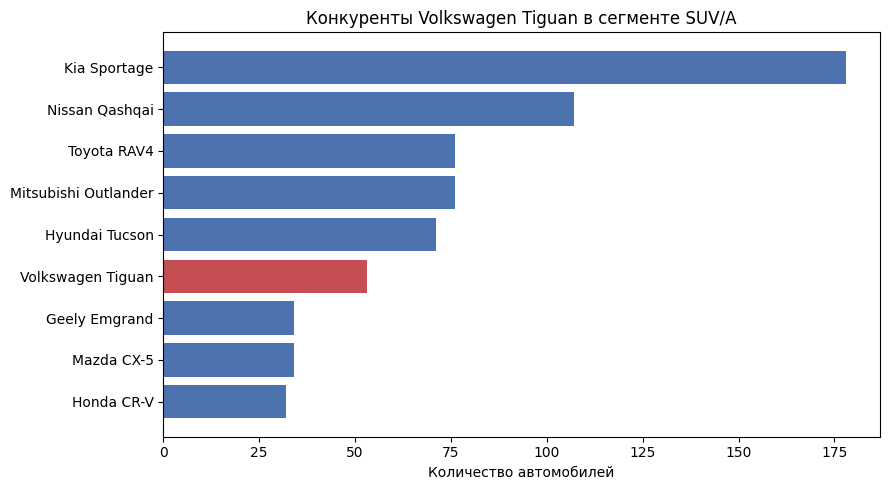

In [10]:
import matplotlib.pyplot as plt

top_competitors = competitors.head(8)
labels = list(top_competitors.index) + ["Volkswagen Tiguan"]
values = list(top_competitors.values) + [tiguan_count]
colors = ["#4C72B0"] * len(top_competitors) + ["#C44E52"]

order = sorted(range(len(values)), key=lambda i: values[i])
labels = [labels[i] for i in order]
values = [values[i] for i in order]
colors = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, values, color=colors)
ax.set_title("Конкуренты Volkswagen Tiguan в сегменте SUV/A")
ax.set_xlabel("Количество автомобилей")
plt.tight_layout()
plt.show()


**Вывод:** Volkswagen Tiguan конкурирует в сегменте **SUV / A**. Его основные конкуренты по объёму продаж:

1. **Kia Sportage** — лидер сегмента, продаж заметно больше, чем у Tiguan
2. **Nissan Qashqai**
3. **Mitsubishi Outlander** и **Toyota RAV4** (почти одинаковый объём)
4. **Hyundai Tucson**

Volkswagen Tiguan по продажам уступает всем перечисленным моделям и занимает более скромное место в сегменте.

## Итоговое резюме

- **Самый популярный бренд** на рынке — Volkswagen (~15%), за ним следуют Renault (~12.5%) и Kia (~9%).
- **Доля Volkswagen в Гомельской области** — около 15%, что соответствует среднему уровню по стране.
- **Kia Sportage** — лидер сегмента SUV/A с долей ~18%, опережая ближайших конкурентов.
- **Основные конкуренты Volkswagen Tiguan** (сегмент SUV/A): Kia Sportage, Nissan Qashqai, Mitsubishi Outlander,
  Toyota RAV4, Hyundai Tucson — Tiguan уступает им по объёму продаж.
